<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


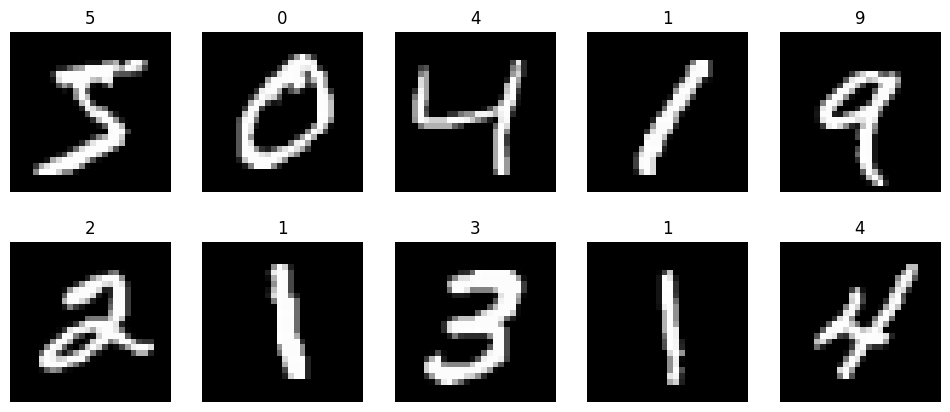

In [8]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [9]:
train_features = []

for img in X_train:
    feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(4,4),
        cells_per_block=(2,2),
        visualize=False
    )
    train_features.append(feature)

train_features = np.array(train_features)

print(train_features.shape)

(60000, 1296)


In [10]:
test_features = []

for img in X_test:
    feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(4,4),
        cells_per_block=(2,2),
        visualize=False
    )
    test_features.append(feature)

test_features = np.array(test_features)

print(test_features.shape)

(10000, 1296)


In [11]:
model = SVC(kernel='linear')

model.fit(train_features, y_train)

SVC(kernel='linear')

In [12]:
y_pred = model.predict(test_features)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy = {:.2f}%".format(accuracy*100))

Accuracy = 97.94%


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 976    0    0    1    0    0    1    1    1    0]
 [   0 1129    2    1    0    0    2    0    1    0]
 [   2    4 1013    3    1    0    1    6    2    0]
 [   0    1    6  991    0    6    0    1    4    1]
 [   3    1    0    0  966    0    1    1    1    9]
 [   1    1    1   12    0  870    2    0    4    1]
 [   8    3    1    0    3    7  936    0    0    0]
 [   1    6   10    4    6    0    0  993    1    7]
 [   4    1    3    6    1    3    2    3  946    5]
 [   1    5    0    4   13    3    0    6    3  974]]


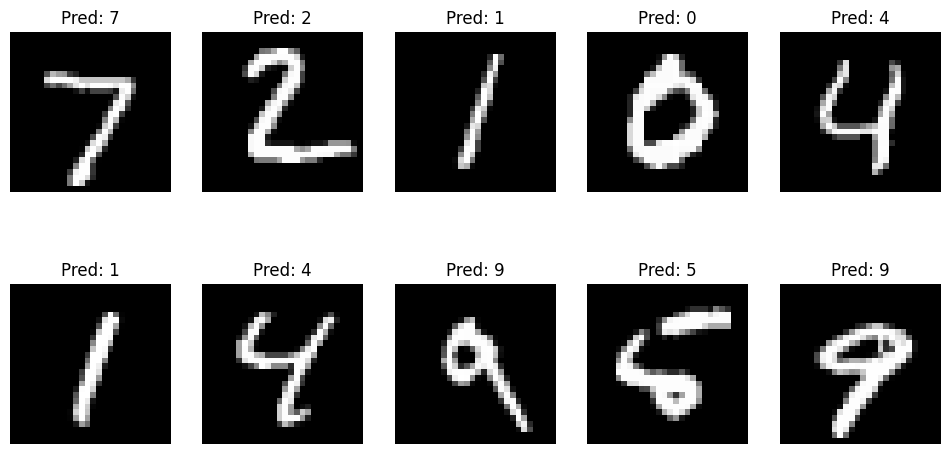

In [16]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Pred: {}".format(y_pred[i]))
    plt.axis('off')

plt.show()

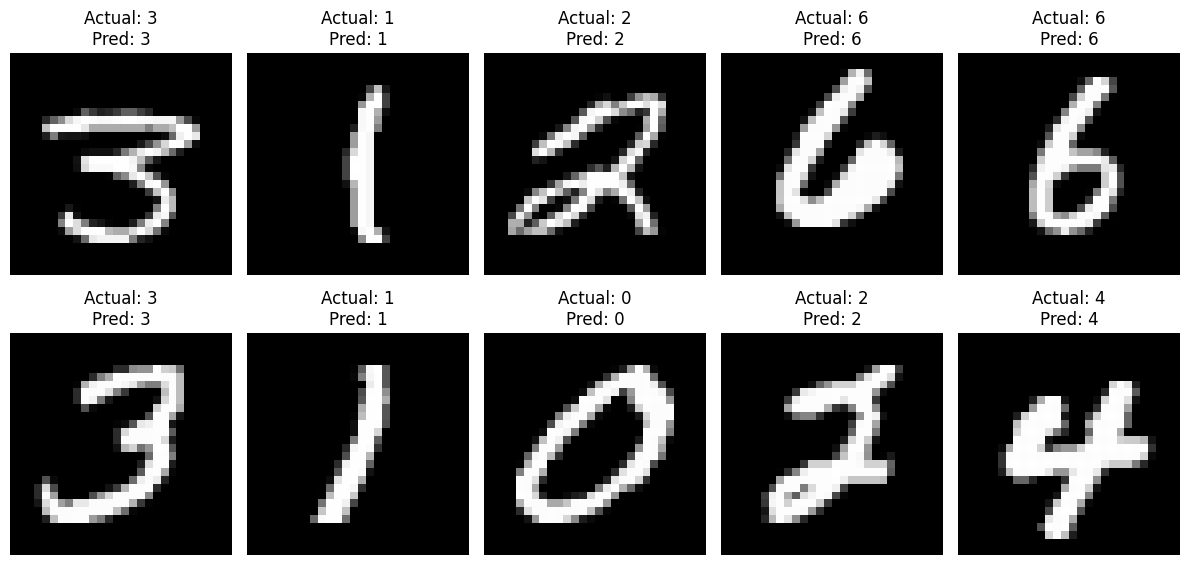

In [17]:
import random

plt.figure(figsize=(12,6))

for i in range(10):

    idx = random.randint(0, len(X_test)-1)

    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title("Actual: {}\nPred: {}".format(y_test[idx], y_pred[idx]))
    plt.axis('off')

plt.tight_layout()
plt.show()